# Análisis Individual Interactivo - Cascada de Detección y Clasificación de Moniliasis en Cacao

Procesa una sola imagen paso a paso con visualizaciones detalladas:
1. **YOLO** → detecta mazorcas
2. **Filtro pre-segmentación**
3. **SAM2** → segmenta con máscara
4. **Filtro post-segmentación**
5. **ConvNeXt Tiny** → clasifica con Grad-CAM

Por cada detección (máx 6) se muestra un subplot de 4 columnas:
- Bounding box original
- Máscara SAM2 superpuesta
- Recorte limpio (fondo negro) entrada del clasificador
- Mapa de calor Grad-CAM

In [1]:
"""

# =============================================================================
# Celda 1: Instalación de dependencias
# =============================================================================
import subprocess
import sys

deps = [
    "ultralytics",
    "torch",
    "torchvision",
    "timm",
    "opencv-python",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pillow",
    "tqdm"
]

for dep in deps:
    print(f"Instalando: {dep}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", dep])
print("\nTodas las dependencias instaladas correctamente.")

"""

'\n\n# =============================================================================\n# Celda 1: Instalación de dependencias\n# =============================================================================\nimport subprocess\nimport sys\n\ndeps = [\n    "ultralytics",\n    "torch",\n    "torchvision",\n    "timm",\n    "opencv-python",\n    "numpy",\n    "pandas",\n    "matplotlib",\n    "seaborn",\n    "scikit-learn",\n    "pillow",\n    "tqdm"\n]\n\nfor dep in deps:\n    print(f"Instalando: {dep}")\n    subprocess.check_call([sys.executable, "-m", "pip", "install", dep])\nprint("\nTodas las dependencias instaladas correctamente.")\n\n'

In [2]:
# =============================================================================
# Celda 2: CONFIGURACIÓN GENERAL Y FUNCIONES AUXILIARES
# =============================================================================
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# ---------------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------------
IMAGE_PATH = r"D:\Python\Notebook\Dataset\DataLocal_Binario\test\img\sano_29.jpg"
RUTA_YOLO = r"D:\Python\Notebook\Modelos\YOLO_Mixto_BA\weights\best.pt"
RUTA_SAM2 = r"D:\Python\Notebook\sam2_l.pt"
RUTA_CONVNEXT = r"D:\Python\Notebook\Modelos\convnext_tiny_mixto_balanceado.pth"

# ---------------------------------------------------------------------------
# CLASES DEL CLASIFICADOR
# ---------------------------------------------------------------------------
CLASES = ["enfermo", "sano"]

# ---------------------------------------------------------------------------
# FILTRO PRE-SEGMENTACIÓN
# ---------------------------------------------------------------------------
PRE_MIN_W = 50
PRE_MIN_H = 50
PRE_MIN_AREA = 3000
PRE_DARK_V_THR = 30
PRE_MAX_DARK_RATIO = 0.5
PRE_CANNY_LOW = 100
PRE_CANNY_HIGH = 200
PRE_MIN_EDGE_DENSITY = 0.01

# ---------------------------------------------------------------------------
# SAM2
# ---------------------------------------------------------------------------
SAM2_CONF = 0.3
SAM2_MASK_THR = 0.5
SAM2_GAUSS_SIGMA = 3.0
SAM2_SHARP_ORIG = 1.5
SAM2_SHARP_BLUR = -0.5
SAM2_BILAT_D = 9
SAM2_BILAT_SIGMA_COLOR = 75
SAM2_BILAT_SIGMA_SPACE = 75
SAM2_BLEND_SHARP = 0.7
SAM2_BLEND_BILAT = 0.3

# ---------------------------------------------------------------------------
# FILTRO POST-SEGMENTACIÓN
# ---------------------------------------------------------------------------
POST_MIN_FG = 0.10
POST_MAX_FG = 0.90
POST_MAX_RECT = 0.95
POST_SQUARE_LOW = 0.95
POST_SQUARE_HIGH = 1.05
POST_SQUARE_FG = 0.80

# ---------------------------------------------------------------------------
# CONVNEXT
# ---------------------------------------------------------------------------
MODEL_ARCH = 'convnext_tiny'
NUM_CLASSES = 2
IMG_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

# ---------------------------------------------------------------------------
# HELPER: PADDING / MARGEN / MASS ACC
# ---------------------------------------------------------------------------
PAD_TARGET_SIZE = 224
CROP_MARGEN = 0.05
MASS_ACC_THRESHOLD = 20

# ---------------------------------------------------------------------------
# VISUALIZACIÓN
# ---------------------------------------------------------------------------
MAX_DETECCIONES = 6
MOSTRAR_MASCARA = True
GROSOR_BBOX = 4
OVERLAY_IMG_PESO = 0.7
OVERLAY_MASK_PESO = 0.3

# ---------------------------------------------------------------------------
# DISPOSITIVO
# ---------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Imagen a procesar: {IMAGE_PATH}")
print(f"Dispositivo: {device}")


def pre_filter(crop):
    h, w = crop.shape[:2]
    area = h * w
    if w < PRE_MIN_W or h < PRE_MIN_H or area < PRE_MIN_AREA:
        return False, "Dimensiones mínimas"
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    if np.sum(hsv[:, :, 2] < PRE_DARK_V_THR) / area > PRE_MAX_DARK_RATIO:
        return False, "Demasiados píxeles oscuros"
    edges = cv2.Canny(crop, PRE_CANNY_LOW, PRE_CANNY_HIGH)
    if np.sum(edges > 0) / area < PRE_MIN_EDGE_DENSITY:
        return False, "Densidad de bordes muy baja"
    return True, ""


def post_filter(mask, crop_shape):
    h, w = crop_shape[:2]
    area_total = h * w
    area_mask = np.sum(mask > 0)
    if area_mask == 0:
        return False, "Máscara vacía"
    prop_fg = area_mask / area_total
    if prop_fg < POST_MIN_FG:
        return False, f"Máscara muy pequeña ({prop_fg:.2%})"
    if prop_fg > POST_MAX_FG:
        return False, f"Máscara muy grande ({prop_fg:.2%})"
    coords = np.column_stack(np.where(mask > 0))
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        bbox_w = x_max - x_min + 1
        bbox_h = y_max - y_min + 1
        extension = area_mask / (bbox_w * bbox_h) if (bbox_w * bbox_h) > 0 else 1
        if extension > POST_MAX_RECT:
            return False, f"Forma muy rectangular (ext={extension:.2f})"
        ratio = bbox_w / bbox_h if bbox_h > 0 else 999
        if POST_SQUARE_LOW < ratio < POST_SQUARE_HIGH and prop_fg > POST_SQUARE_FG:
            return False, "Máscara casi cuadrada y llena"
    return True, ""


def resize_con_padding(img, target_size=None):
    if target_size is None:
        target_size = PAD_TARGET_SIZE
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return None
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    x_off = (target_size - new_w) // 2
    y_off = (target_size - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def mass_accuracy(masked_img, threshold=None):
    if threshold is None:
        threshold = MASS_ACC_THRESHOLD
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    total = gray.size
    if total == 0:
        return 0.0
    return float(np.sum(gray > threshold)) / total


def crop_con_margen(img, x1, y1, x2, y2, margen=None):
    if margen is None:
        margen = CROP_MARGEN
    h_img, w_img = img.shape[:2]
    ancho = x2 - x1
    alto = y2 - y1
    dx = int(ancho * margen)
    dy = int(alto * margen)
    return img[
        max(0, y1 - dy):min(h_img, y2 + dy),
        max(0, x1 - dx):min(w_img, x2 + dx)
    ].copy()


def preprocess_for_segmentation(img_rgb):
    blurred = cv2.GaussianBlur(img_rgb, (0, 0), SAM2_GAUSS_SIGMA)
    img_sharp = cv2.addWeighted(img_rgb, SAM2_SHARP_ORIG, blurred, SAM2_SHARP_BLUR, 0)
    img_bilateral = cv2.bilateralFilter(img_sharp, SAM2_BILAT_D, SAM2_BILAT_SIGMA_COLOR, SAM2_BILAT_SIGMA_SPACE)
    img_enhanced = cv2.addWeighted(img_sharp, SAM2_BLEND_SHARP, img_bilateral, SAM2_BLEND_BILAT, 0)
    return np.clip(img_enhanced, 0, 255).astype(np.uint8)


def get_best_mask(masks_np, img_shape):
    h, w = img_shape[:2]
    img_center = np.array([h / 2, w / 2])
    mask_list = [masks_np[i] for i in range(masks_np.shape[0])]
    def distance_to_center(mask):
        coords = np.column_stack(np.where(mask == 255))
        if len(coords) == 0:
            return float('inf')
        centroid = coords.mean(axis=0)
        return np.linalg.norm(centroid - img_center)
    sorted_masks = sorted(mask_list, key=distance_to_center)
    return sorted_masks[0] if sorted_masks else None

Imagen a procesar: D:\Python\Notebook\Dataset\DataLocal_Binario\test\img\sano_29.jpg
Dispositivo: cuda


---
## Cargar Modelos
---

In [3]:
# =============================================================================
# Celda 3: Cargar YOLO
# =============================================================================
from ultralytics import YOLO

print("Cargando YOLO...")
modelo_yolo = YOLO(RUTA_YOLO)
modelo_yolo.to(device)
print("YOLO cargado.")

Cargando YOLO...
YOLO cargado.


In [4]:
# =============================================================================
# Celda 4: Cargar SAM2
# =============================================================================
from ultralytics import SAM

print("Cargando SAM2...")
model_sam = SAM(RUTA_SAM2)
print("SAM2 cargado.")
print("SAM2 cargado.")

Cargando SAM2...
SAM2 cargado.
SAM2 cargado.


In [5]:
# =============================================================================
# Celda 5: Cargar ConvNeXt con hook para Grad-CAM
# =============================================================================
import timm
from torchvision import transforms

print("Cargando ConvNeXt...")
modelo_convnext = timm.create_model(MODEL_ARCH, pretrained=False, num_classes=NUM_CLASSES)
checkpoint = torch.load(RUTA_CONVNEXT, map_location=device, weights_only=True)
if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint
modelo_convnext.load_state_dict(state_dict)
modelo_convnext.to(device)
modelo_convnext.eval()
print("ConvNeXt cargado.")

# --- Registrar hooks para Grad-CAM ---
activaciones = {}
gradientes = {}


def forward_hook(module, input, output):
    activaciones["value"] = output


def backward_hook(module, grad_input, grad_output):
    gradientes["value"] = grad_output[0]


target_layer = modelo_convnext.stages[-1].blocks[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)
print(f"Hook registrado en: model.stages[-1].blocks[-1]")

# Transformación para ConvNeXt:
# Primero se aplica resize_con_padding (manteniendo aspect ratio con bordes negros)
# sobre la imagen numpy, luego ToTensor + Normalize.
transform_clf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN,
                         std=NORM_STD)
])

Cargando ConvNeXt...
ConvNeXt cargado.
Hook registrado en: model.stages[-1].blocks[-1]


---
## Procesar Imagen
---

In [6]:
# =============================================================================
# Celda 6: Procesar imagen - detección, segmentación, clasificación y visualización
# =============================================================================
import matplotlib.patches as mpatches

# Leer imagen
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {IMAGE_PATH}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Imagen cargada: {Path(IMAGE_PATH).name} ({img.shape[1]}x{img.shape[0]})")

# --- YOLO: detectar ---
resultados = modelo_yolo(img, verbose=False)

detecciones = []
if len(resultados) > 0 and resultados[0].boxes is not None:
    boxes = resultados[0].boxes.xyxy.cpu().numpy()
    confs = resultados[0].boxes.conf.cpu().numpy()
    for box, conf in zip(boxes, confs):
        x1, y1, x2, y2 = map(int, box)
        detecciones.append({
            "bbox": [max(0, x1), max(0, y1), min(img.shape[1], x2), min(img.shape[0], y2)],
            "confianza_yolo": float(conf)
        })

print(f"Detecciones YOLO: {len(detecciones)}")

# Limitar al máximo para visualización
detecciones = detecciones[:MAX_DETECCIONES]
n_dets = len(detecciones)

# Para cada detección: procesar cascada
resultados_det = []

for idx, det in enumerate(detecciones):
    x1, y1, x2, y2 = det["bbox"]
    info = {"idx": idx, "bbox": det["bbox"], "conf_yolo": det["confianza_yolo"]}

    # Recortar con margen
    crop = crop_con_margen(img, x1, y1, x2, y2)
    if crop is None or crop.size == 0:
        info["estado"] = "No Procesable"
        info["razon"] = "Error al recortar"
        resultados_det.append(info)
        continue

    info["crop"] = crop

    # Pre-filter
    pasa_pre, razon_pre = pre_filter(crop)
    info["pre_filter_pasa"] = pasa_pre
    info["pre_filter_razon"] = razon_pre

    if not pasa_pre:
        info["estado"] = "No Procesable"
        info["razon"] = f"Pre-filter: {razon_pre}"
        resultados_det.append(info)
        continue

    # SAM2: segmentar
    try:
        # Preprocesar como en segmentadorManual.py (realzar bordes antes de SAM2)
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        enhanced = preprocess_for_segmentation(crop_rgb)
        results_sam = model_sam.predict(source=enhanced, conf=SAM2_CONF, device=device, verbose=False)

        if len(results_sam) == 0 or results_sam[0].masks is None or len(results_sam[0].masks.data) == 0:
            info["estado"] = "No Procesable"
            info["razon"] = "SAM2 sin máscaras"
            resultados_det.append(info)
            continue

        # Umbral > 0.5 y selección centrada (como en segmentadorManual)
        masks_np = results_sam[0].masks.data.cpu().numpy().astype(np.uint8)
        masks_np = (masks_np > SAM2_MASK_THR).astype(np.uint8) * 255
        best_mask = get_best_mask(masks_np, crop.shape)
        if best_mask is None:
            info["estado"] = "No Procesable"
            info["razon"] = "Ninguna máscara válida"
            resultados_det.append(info)
            continue
        mask = best_mask
        info["mask"] = mask
        info["score_sam"] = 0.0

    except Exception as e:
        info["estado"] = "No Procesable"
        info["razon"] = f"Error SAM2: {str(e)}"
        resultados_det.append(info)
        continue
    # Post-filter
    pasa_post, razon_post = post_filter(mask, crop.shape)
    info["post_filter_pasa"] = pasa_post
    info["post_filter_razon"] = razon_post

    if not pasa_post:
        info["estado"] = "No Procesable"
        info["razon"] = f"Post-filter: {razon_post}"
        resultados_det.append(info)
        continue

    # Aplicar máscara
    masked = cv2.bitwise_and(crop, crop, mask=mask)
    info["masked"] = masked
    info["mass_accuracy"] = mass_accuracy(masked)

    # Clasificar con ConvNeXt
    masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)
    masked_padded = resize_con_padding(masked_rgb, IMG_SIZE)
    tensor = transform_clf(masked_padded).unsqueeze(0).to(device)

    with torch.no_grad():
        salida = modelo_convnext(tensor)
        probs = torch.softmax(salida, dim=1)[0]
        pred_cls = int(torch.argmax(probs).item())
        confianza = float(probs[pred_cls].item())

    info["prediccion"] = CLASES[pred_cls]
    info["confianza_clf"] = confianza
    info["input_clf"] = masked

    # Grad-CAM
    modelo_convnext.zero_grad()
    salida = modelo_convnext(tensor)
    target_class = salida.argmax(dim=1).item()
    salida[0, target_class].backward()

    with torch.no_grad():
        pesos = gradientes["value"].mean(dim=[2, 3], keepdim=True)
        cam = (pesos * activaciones["value"]).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam_map = cam.squeeze().cpu().numpy()
        cam_map = (cam_map - cam_map.min()) / (cam_map.max() - cam_map.min() + 1e-8)

    info["gradcam"] = cam_map
    info["estado"] = "Procesable"
    resultados_det.append(info)

print("Procesamiento de cascada completado.")

Imagen cargada: sano_29.jpg (3072x4096)
Detecciones YOLO: 6
Procesamiento de cascada completado.


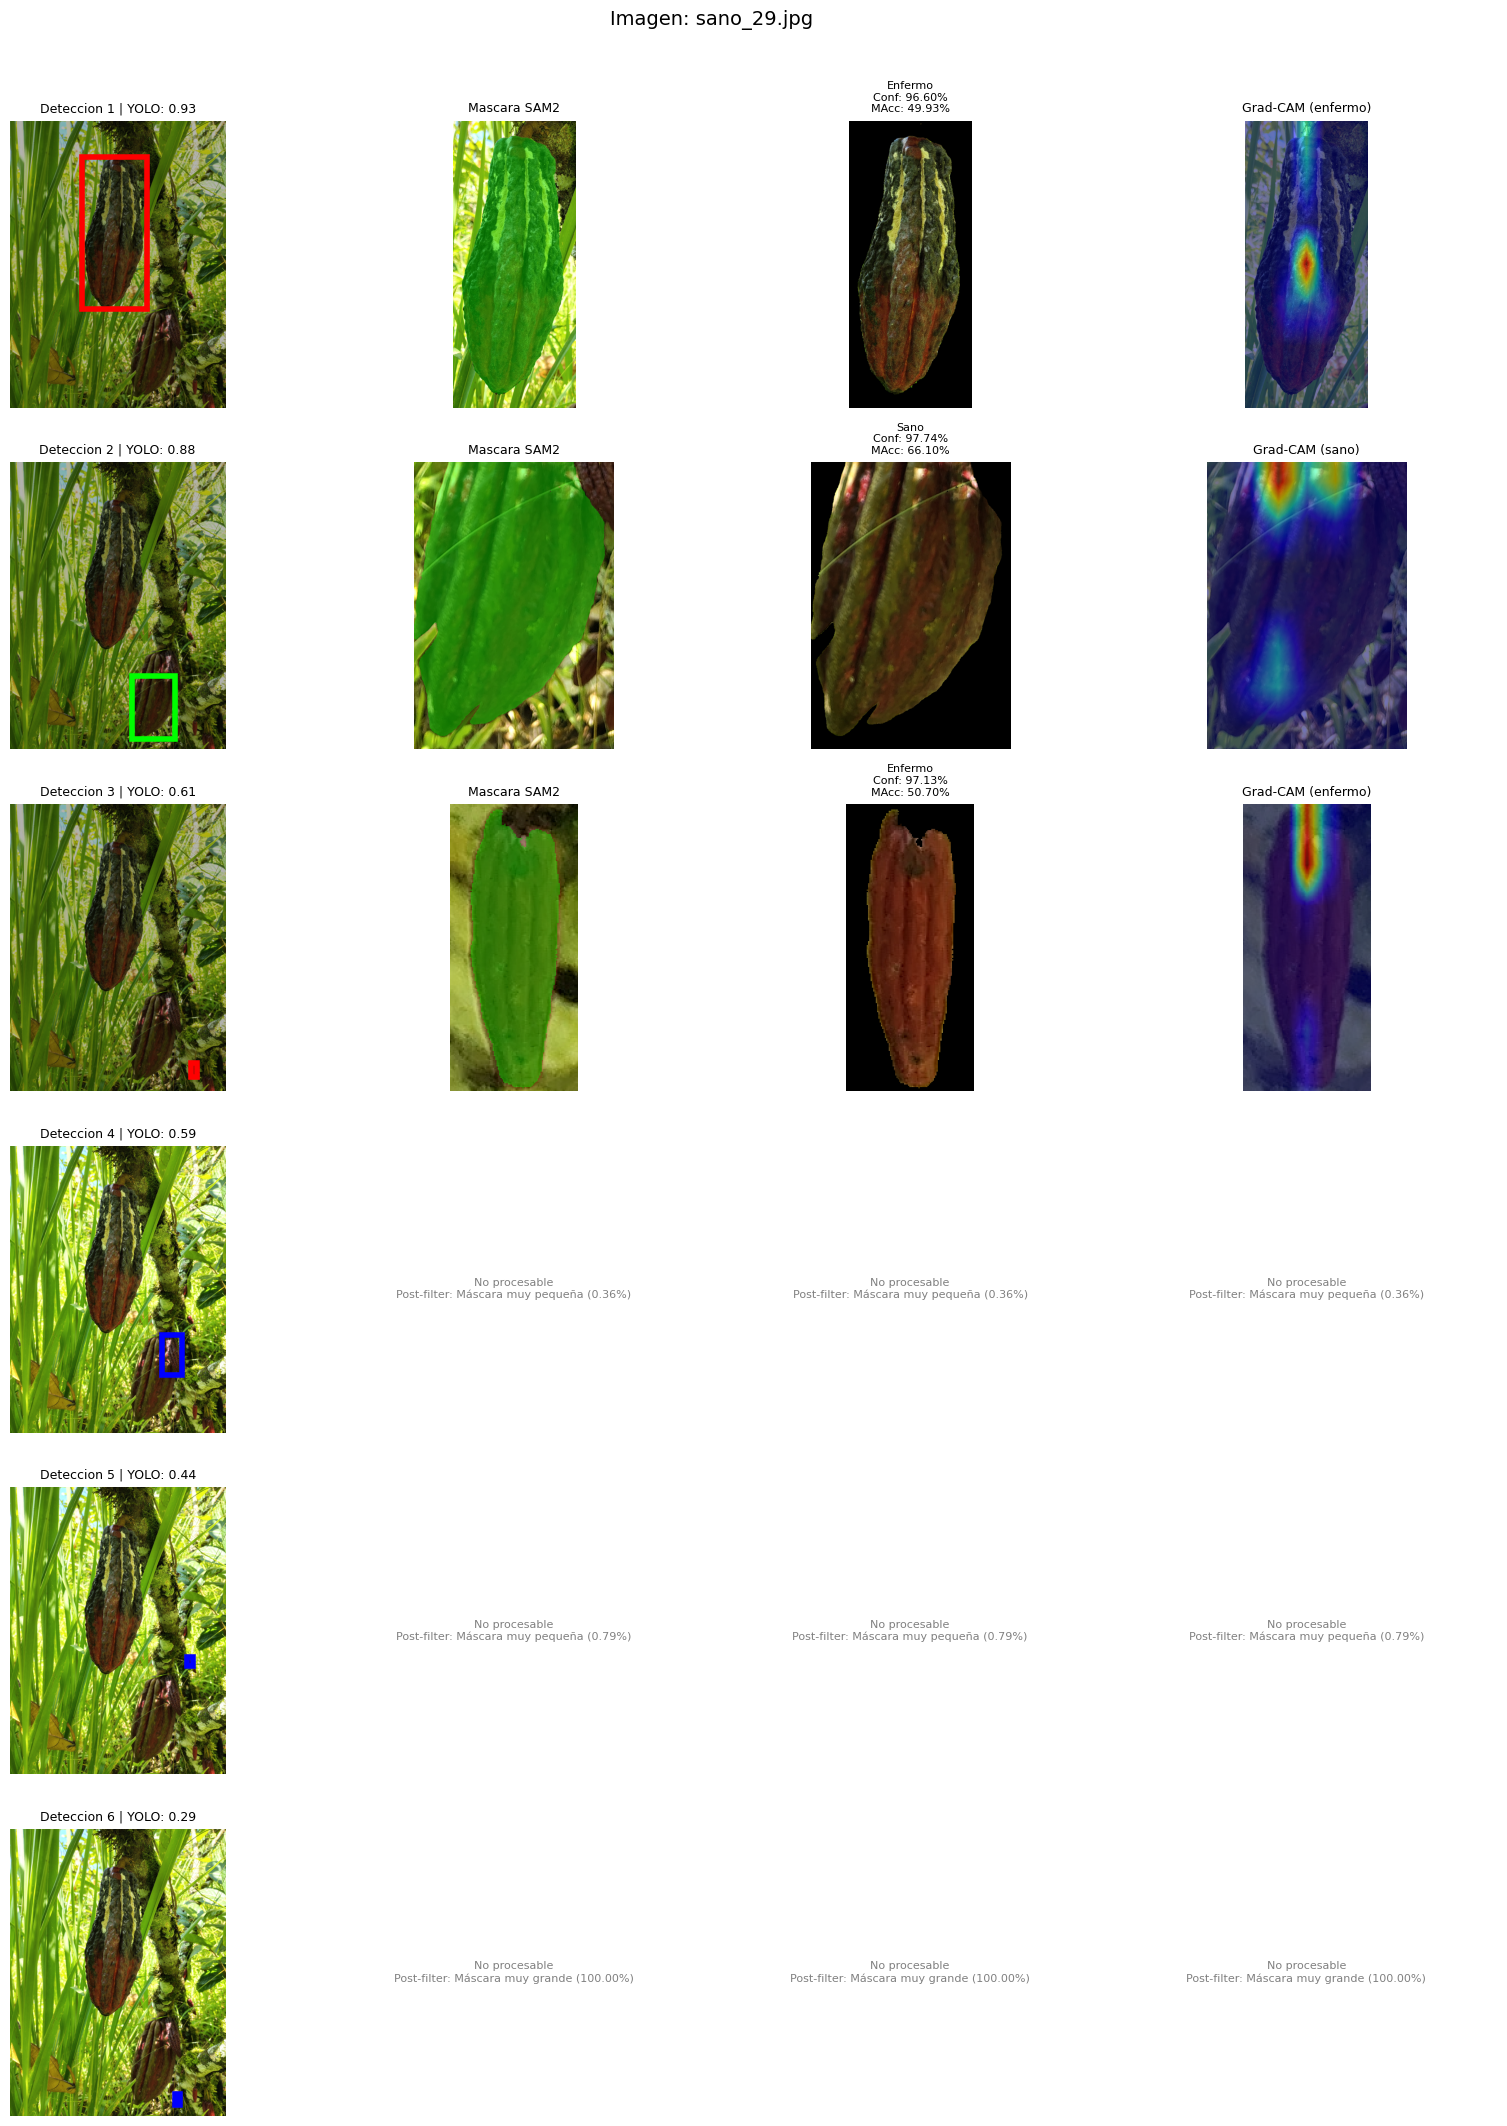

RESUMEN - sano_29.jpg
Mazorcas detectadas: 6
  - Sanas:       1
  - Enfermas:    2
  - Procesables: 3
  - No proc.:    3
Motivos de rechazo:
  - Deteccion #4: Post-filter: Máscara muy pequeña (0.36%)
  - Deteccion #5: Post-filter: Máscara muy pequeña (0.79%)
  - Deteccion #6: Post-filter: Máscara muy grande (100.00%)


In [7]:
# =============================================================================
# Celda 7: Visualización paso a paso
# =============================================================================
if n_dets == 0:
    print("No se detectaron mazorcas en la imagen.")
else:
    n_cols = 4
    fig, axes = plt.subplots(n_dets, n_cols,
                             figsize=(n_cols * 4, n_dets * 3.5),
                             squeeze=False)

    for i, info in enumerate(resultados_det):
        x1, y1, x2, y2 = info["bbox"]
        es_procesable = info["estado"] == "Procesable"
        razon = info.get("razon", "")

        # Columna 0: Original con bbox
        ax0 = axes[i, 0]
        img_copy = img_rgb.copy()
        if es_procesable and info["prediccion"] == "enfermo":
            color_box = "red"
        elif es_procesable:
            color_box = "lime"
        else:
            color_box = "blue"
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=GROSOR_BBOX, edgecolor=color_box,
            facecolor="none"
        )
        ax0.add_patch(rect)
        if MOSTRAR_MASCARA and es_procesable and "mask" in info:
            m = info["mask"]
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            if m.shape[0] != bbox_h or m.shape[1] != bbox_w:
                m = cv2.resize(m, (bbox_w, bbox_h), interpolation=cv2.INTER_NEAREST)
            overlay = np.zeros_like(img_copy, dtype=np.float32)
            color_mask = [1, 1, 0]
            overlay[y1:y1 + bbox_h, x1:x1 + bbox_w][m > 0] = color_mask
            img_copy = (img_copy.astype(np.float32) * 0.7 + overlay * 0.3).astype(np.uint8)
        ax0.imshow(img_copy)
        ax0.set_title(f"Deteccion {i + 1} | YOLO: {info['conf_yolo']:.2f}", fontsize=9)
        ax0.axis("off")

        # Columna 1: Mascara SAM2 (solo si procesable)
        ax1 = axes[i, 1]
        if es_procesable and "crop" in info and "mask" in info:
            crop_rgb = cv2.cvtColor(info["crop"], cv2.COLOR_BGR2RGB)
            mask_overlay = crop_rgb.copy()
            mask_alpha = 0.4
            mask_colored = np.zeros_like(crop_rgb)
            mask_colored[:, :, 1] = 255
            mask_bool = info["mask"] > 0
            if mask_bool.ndim == 3:
                mask_bool = mask_bool[:, :, 0]
            mask_overlay[mask_bool] = (
                crop_rgb[mask_bool] * (1 - mask_alpha) + mask_colored[mask_bool] * mask_alpha
            ).astype(np.uint8)
            ax1.imshow(mask_overlay)
            ax1.set_title(f"Mascara SAM2", fontsize=9)
        else:
            ax1.text(0.5, 0.5, f"No procesable\n{razon}", ha="center", va="center",
                    transform=ax1.transAxes, fontsize=8, color="gray")
        ax1.axis("off")

        # Columna 2: Recorte enmascarado (entrada del clasificador)
        ax2 = axes[i, 2]
        if es_procesable and "input_clf" in info:
            input_rgb = cv2.cvtColor(info["input_clf"], cv2.COLOR_BGR2RGB)
            ax2.imshow(input_rgb)
            titulo_col2 = f"{info['prediccion'].capitalize()}\nConf: {info['confianza_clf']:.2%}\nMAcc: {info['mass_accuracy']:.2%}"
            ax2.set_title(titulo_col2, fontsize=8)
        else:
            ax2.text(0.5, 0.5, f"No procesable\n{razon}", ha="center", va="center",
                    transform=ax2.transAxes, fontsize=8, color="gray")
        ax2.axis("off")

        # Columna 3: Grad-CAM sobre el crop original (sin mascara)
        ax3 = axes[i, 3]
        if es_procesable and "crop" in info and "gradcam" in info:
            crop_rgb_gradcam = cv2.cvtColor(info["crop"], cv2.COLOR_BGR2RGB)
            ax3.imshow(crop_rgb_gradcam)
            cam_map = info["gradcam"]
            cam_resized = cv2.resize(cam_map,
                                     (crop_rgb_gradcam.shape[1], crop_rgb_gradcam.shape[0]),
                                     interpolation=cv2.INTER_LINEAR)
            ax3.imshow(cam_resized, cmap="jet", alpha=0.55)
            ax3.set_title(f"Grad-CAM ({info['prediccion']})", fontsize=9)
        else:
            ax3.text(0.5, 0.5, f"No procesable\n{razon}", ha="center", va="center",
                    transform=ax3.transAxes, fontsize=8, color="gray")
        ax3.axis("off")

    plt.suptitle(f"Imagen: {Path(IMAGE_PATH).name}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# --- Resumen de resultados ---
n_total = len(resultados_det)
n_proc = sum(1 for r in resultados_det if r["estado"] == "Procesable")
n_sanos = sum(1 for r in resultados_det if r["estado"] == "Procesable" and r["prediccion"] == "sano")
n_enfermos = sum(1 for r in resultados_det if r["estado"] == "Procesable" and r["prediccion"] == "enfermo")
n_noproc = n_total - n_proc
print("=" * 50)
print(f"RESUMEN - {Path(IMAGE_PATH).name}")
print("=" * 50)
print(f"Mazorcas detectadas: {n_total}")
print(f"  - Sanas:       {n_sanos}")
print(f"  - Enfermas:    {n_enfermos}")
print(f"  - Procesables: {n_proc}")
print(f"  - No proc.:    {n_noproc}")
if n_noproc > 0:
    print("Motivos de rechazo:")
    for r in resultados_det:
        if r["estado"] != "Procesable":
            print(f"  - Deteccion #{r['idx'] + 1}: {r.get('razon', 'Desconocido')}")
print("=" * 50)


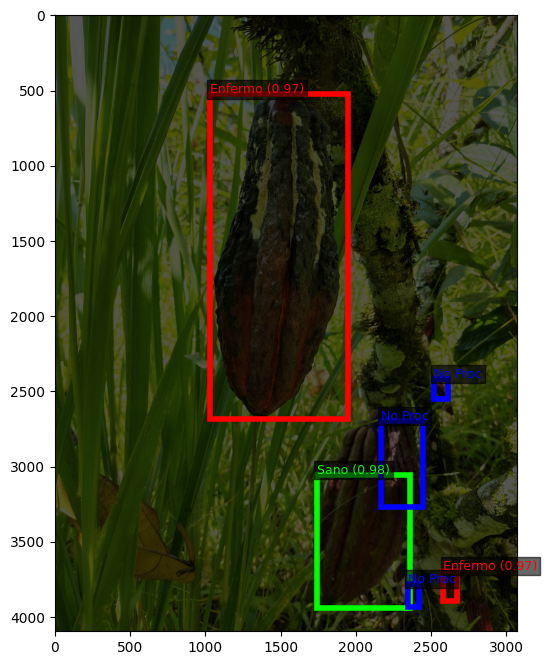

In [8]:
# =============================================================================
# Celda 8: Imagen final con todos los bounding boxes
# =============================================================================
img_final = img_rgb.copy()

n_procesables = 0
n_no_procesables = 0
n_sanos = 0
n_enfermos = 0
rechazos = []

plt.figure(figsize=(10, 8))
plt.imshow(img_final)
for info in resultados_det:
        x1, y1, x2, y2 = info["bbox"]
        es_procesable = info["estado"] == "Procesable"

        if es_procesable:
            n_procesables += 1
            if info["prediccion"] == "sano":
                n_sanos += 1
                color_box = "lime"
                etiqueta = f"Sano ({info['confianza_clf']:.2f})"
            else:
                n_enfermos += 1
                color_box = "red"
                etiqueta = f"Enfermo ({info['confianza_clf']:.2f})"
        else:
            n_no_procesables += 1
            rechazos.append(info["razon"])
            etiqueta = "No Proc"
            color_box = "blue"

        rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=GROSOR_BBOX, edgecolor=color_box, facecolor="none")
        plt.gca().add_patch(rect)
        plt.text(x1, y1 - 8, etiqueta, fontsize=9, color=color_box,
                 bbox=dict(facecolor="black", alpha=0.6, pad=2))

        # MÃ¡scara SAM semi-transparente
        if MOSTRAR_MASCARA and es_procesable and "mask" in info:
            m = info["mask"]
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            if m.shape[0] != bbox_h or m.shape[1] != bbox_w:
                m = cv2.resize(m, (bbox_w, bbox_h), interpolation=cv2.INTER_NEAREST)
            overlay_mask = np.zeros((img_final.shape[0], img_final.shape[1], 3), dtype=np.float32)
            overlay_color = [1, 1, 0]
            overlay_mask[y1:y1 + bbox_h, x1:x1 + bbox_w][m > 0] = overlay_color
            img_final = (img_final.astype(np.float32) * OVERLAY_IMG_PESO + overlay_mask * OVERLAY_MASK_PESO).astype(np.uint8)
            # Re-muestrear para reflejar overlay
            plt.gca().images[0].set_data(img_final)
